# 11-PEFT & The Mathematics of LoRA

In Lesson 10, we performed Supervised Fine-Tuning (SFT) on `DistilBERT`. It was easy because the model only had 66 million parameters.

But welcome to the modern era of Large Language Models (LLMs). If your company wants to fine-tune **Llama-3 (70 Billion parameters)**, you will hit a catastrophic hardware wall. During Backpropagation, the Adam optimizer requires storing the gradients, the momentum, and the variance for every single weight. To perform standard SFT on a 70B model, you need roughly **1.5 Terabytes of VRAM** (about 20x H100 GPUs linked together).

To fine-tune modern LLMs on consumer hardware, we must abandon full architectural backpropagation and embrace **Parameter-Efficient Fine-Tuning (PEFT)**. Today, we master the undisputed king of PEFT: **Low-Rank Adaptation (LoRA)**, a mathematical masterpiece published by Microsoft in 2021.

Let's set up our PyTorch environment to perform matrix decomposition.

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch LoRA Mathematics Environment Ready.")

✅ PyTorch LoRA Mathematics Environment Ready.


# 1. The VRAM Wall & The Intrinsic Rank Hypothesis

If a pre-trained LLM is a massive $4096 \times 4096$ weight matrix ($W$), we historically update it by finding a massive $4096 \times 4096$ gradient matrix ($\Delta W$).


$$W_{new} = W_{old} + \Delta W$$

Microsoft researchers asked a brilliant mathematical question: **Does the model actually need all $16.7$ million parameters in $\Delta W$ to learn a new task?**

In linear algebra, a matrix has a **Rank**. A full-rank matrix contains completely independent, unique information in every row and column. But researchers hypothesized that LLMs are heavily over-parameterized. When an LLM learns a new task (like writing Python code instead of English), the actual "knowledge update" has a very low **Intrinsic Rank**. It only needs a tiny handful of fundamental mathematical directions to change its behavior.

# 2. The Mathematics of LoRA (Low-Rank Decomposition)

If the massive update matrix $\Delta W$ has a low intrinsic rank, we don't need to calculate or store it directly. We can mathematically **decompose** it into two tiny matrices: $A$ and $B$.

Let $W \in \mathbb{R}^{d \times k}$ be the frozen, pre-trained weight matrix.
Instead of updating $W$, we freeze it completely. We then create two small trainable matrices, where $r$ (the rank) is a tiny number like $8$ or $16$:

1. **Matrix $B$**: Shape $\mathbb{R}^{d \times r}$
2. **Matrix $A$**: Shape $\mathbb{R}^{r \times k}$

By multiplying $B \times A$, we mathematically recreate a matrix of the exact same size as the original $W$, but using a fraction of the parameters!

$$\Delta W = B A$$

$$h = W x + \Delta W x = W x + B A x$$

### The Initialization Trick (The Calculus of Zero)

How do we bolt $A$ and $B$ onto a 70-Billion parameter network without instantly destroying the model's brain on Step 1?

* Matrix $A$ is initialized using random Gaussian noise.
* Matrix $B$ is initialized to **exactly zero**.

Because $B$ is zero, $B \times A = 0$. On the very first forward pass, the LoRA adapter outputs absolutely nothing. The network behaves exactly like the frozen base model. But because the gradients can flow through the zero-matrix during Backpropagation, $B$ slowly wakes up and begins learning!

# 3. The Scaling Factor ($\alpha$)

In production, LoRA introduces one more mathematical variable: **Alpha ($\alpha$)**.
When we add the LoRA output to the base model output, we scale it by $\frac{\alpha}{r}$.

$$h = W x + \frac{\alpha}{r} (B A x)$$

Why? As you change the rank ($r$) from 8 to 16 to 32, the raw mathematical magnitude of the $B \times A$ multiplication increases. By scaling the output by $\frac{\alpha}{r}$, we stabilize the variance of the activations. This allows engineers to change the rank $r$ during experimentation without having to constantly retrain their Learning Rates!

# 4. Building LoRA from Scratch in PyTorch

To prove how efficient this is, we are going to build a standard `nn.Linear` layer that simulates a single massive Attention matrix inside Llama-3. We will then manually code a LoRA injection class, graft it onto the linear layer, and calculate the exact mathematical parameter savings.

--- 🧠 Simulating Matrix Decomposition (Rank 8) ---

--- 🧮 Mathematical Parameter Autopsy ---
Base Model Parameters (Frozen): 16,777,216
LoRA Trainable Parameters:      65,536
Percentage of Trainable Weights: 0.3906%

Mathematical difference between Base and LoRA on Step 1: 0.0
Insight: Because Matrix B is initialized to 0.0, the LoRA output perfectly matches the base model. The network is completely stabilized for training!


/tmp/ipykernel_21683/876301631.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=values, palette=["#e74c3c", "#2ecc71"], ax=ax)


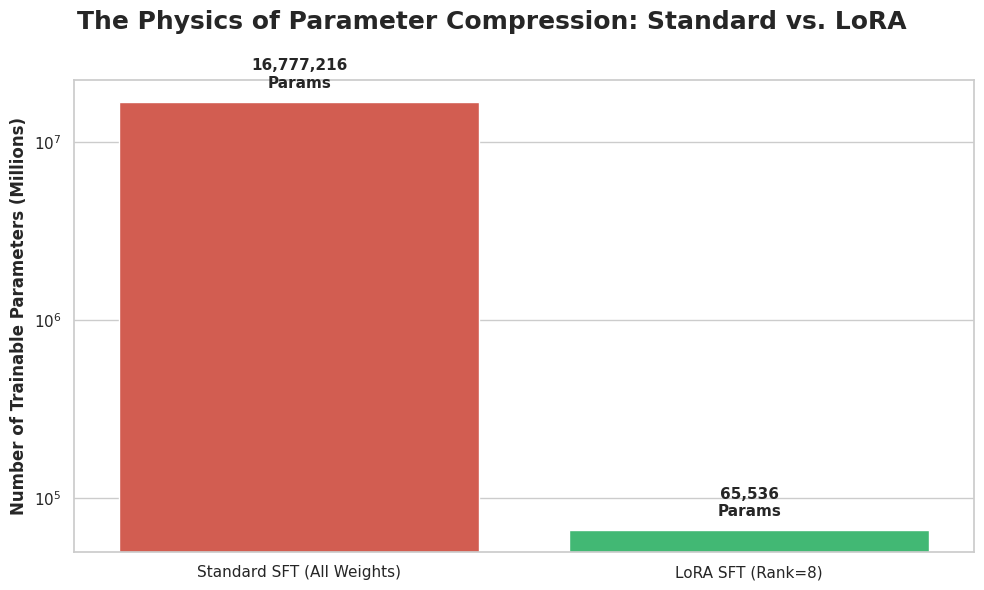

In [4]:
# 1. Define the Enterprise Dimensions (Simulating Llama-3 Attention)
D_IN = 4096
D_OUT = 4096
RANK = 8   # The ultra-low intrinsic rank!
ALPHA = 16 # Standard scaling constant

print(f"--- 🧠 Simulating Matrix Decomposition (Rank {RANK}) ---")

# 2. Architect the LoRA Layer
class LoRALinear(nn.Module):
    def __init__(self, linear_layer: nn.Linear, rank: int, alpha: int):
        super().__init__()
        # 1. Freeze the original massive base weights
        self.linear = linear_layer
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False
            
        # Extract dimensions
        d_out, d_in = self.linear.weight.shape
        
        # 2. Architect the Low-Rank Matrices (A and B)
        # A maps from Input Dimension -> Rank
        self.lora_A = nn.Parameter(torch.empty(rank, d_in))
        # B maps from Rank -> Output Dimension
        self.lora_B = nn.Parameter(torch.empty(d_out, rank))
        
        self.scaling = alpha / rank
        self.reset_parameters()

    def reset_parameters(self):
        # The Zero-Initialization Trick!
        # A gets standard Kaiming (He) initialization
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        # B gets EXACTLY zeros.
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        # 1. Standard Forward Pass through the frozen base
        base_output = self.linear(x)
        
        # 2. Forward Pass through LoRA: x -> A -> B
        # Shape shifts: [Batch, 4096] -> [Batch, 8] -> [Batch, 4096]
        lora_output = (x @ self.lora_A.T) @ self.lora_B.T
        
        # 3. Add them together with the scaling factor
        return base_output + (lora_output * self.scaling)

# 3. Execute the Instantiation
# Create a standard massive linear layer
base_layer = nn.Linear(D_IN, D_OUT, bias=False)
base_params = sum(p.numel() for p in base_layer.parameters())

# Inject LoRA
lora_layer = LoRALinear(base_layer, rank=RANK, alpha=ALPHA)

# Count the trainable parameters (Only A and B!)
trainable_params = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)

print("\n--- 🧮 Mathematical Parameter Autopsy ---")
print(f"Base Model Parameters (Frozen): {base_params:,}")
print(f"LoRA Trainable Parameters:      {trainable_params:,}")
reduction = (trainable_params / base_params) * 100
print(f"Percentage of Trainable Weights: {reduction:.4f}%")

# 4. Proving the Zero-Initialization Physics
test_input = torch.randn(1, D_IN)

with torch.no_grad():
    raw_base_out = base_layer(test_input)
    lora_injected_out = lora_layer(test_input)
    
# Calculate the absolute difference between the base model and the LoRA model on Step 1
difference = torch.abs(raw_base_out - lora_injected_out).sum().item()
print(f"\nMathematical difference between Base and LoRA on Step 1: {difference}")
print("Insight: Because Matrix B is initialized to 0.0, the LoRA output perfectly matches the base model. The network is completely stabilized for training!")

# 5. Visualizing the Memory Savings
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("The Physics of Parameter Compression: Standard vs. LoRA", fontsize=18, fontweight='bold')

categories = ['Standard SFT (All Weights)', f'LoRA SFT (Rank={RANK})']
values = [base_params, trainable_params]

sns.barplot(x=categories, y=values, palette=["#e74c3c", "#2ecc71"], ax=ax)
ax.set_ylabel("Number of Trainable Parameters (Millions)", fontsize=12, fontweight='bold')
ax.set_yscale('log') # Log scale necessary because the difference is so extreme!

# Annotate values
for i, v in enumerate(values):
    ax.text(i, v * 1.2, f"{v:,}\nParams", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of LoRA like **Correcting a massive, ancient Masterpiece Painting**:

* **Standard SFT (Full Fine-Tuning)**: Your company buys a massive, priceless 100-foot mural (the 70B Foundation Model). Your boss asks you to add sunglasses to one of the characters. To do this, you rent an equally massive 100-foot blank canvas, trace the entire painting perfectly, paint the sunglasses on the new canvas, and throw the old mural away. It costs a fortune in paint, storage, and time (VRAM usage).
* **LoRA (Low-Rank Adaptation)**: You realize the fundamental structure of the mural is already perfect. Instead of repainting the entire thing, you take a tiny transparent sticky note (Rank $r=8$), draw the sunglasses on it, and stick it directly over the character's face.
* The massive mural remains completely untouched (Frozen Base Model).
* You only had to pay for a tiny sticky note (Trainable Parameters).
* If you later want to take the sunglasses off and give the character a hat, you just peel off the sticky note and swap it for a new one without ever touching the 100-foot canvas! (Swapping LoRA adapters on the fly during inference).